# 📊 Introdução à Teoria dos Grafos

**Autor:** Thiago de Souza Rodrigues  
**Email:** thiagothiago@cefetmg.br

---

## 1. Motivação

### 🖥️ Situação de Exemplo

Suponha que existam **seis sistemas computacionais** (A, B, C, D, E, e F) interconectados entre si.

Esta informação pode ser representada por um **diagrama chamado de grafo**, que identifica unicamente as conexões entre os sistemas.

### Objetos Especiais em um Grafo:
- **Vértices** (nós): Representam os sistemas
- **Arestas** (conexões): Representam as interconexões entre os sistemas

In [10]:
# Importando as bibliotecas necessárias
import networkx as nx
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Configuração de estilo
plt.style.use('default')
%matplotlib inline

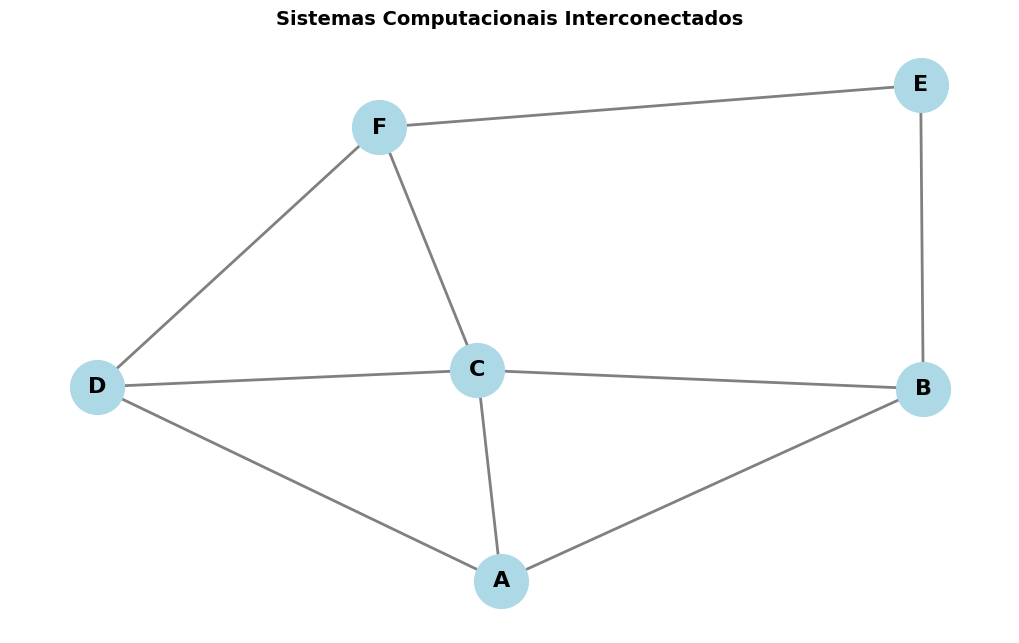

Número de sistemas (vértices): 6
Número de conexões (arestas): 9


In [11]:
# Exemplo de motivação: Sistemas computacionais interconectados
G_motivacao = nx.Graph()

# Adicionando vértices (sistemas)
sistemas = ['A', 'B', 'C', 'D', 'E', 'F']
G_motivacao.add_nodes_from(sistemas)

# Adicionando arestas (conexões entre sistemas)
conexoes = [
    ('A', 'B'), ('A', 'C'), ('A', 'D'),
    ('B', 'C'), ('B', 'E'),
    ('C', 'D'), ('C', 'F'),
    ('D', 'F'),
    ('E', 'F')
]
G_motivacao.add_edges_from(conexoes)

# Visualização
plt.figure(figsize=(10, 6))
pos = nx.spring_layout(G_motivacao, seed=42)
nx.draw(G_motivacao, pos, 
        with_labels=True, 
        node_color='lightblue', 
        node_size=1500,
        font_size=16,
        font_weight='bold',
        edge_color='gray',
        width=2)
plt.title('Sistemas Computacionais Interconectados', fontsize=14, fontweight='bold')
plt.axis('off')
plt.tight_layout()
plt.show()

print(f"Número de sistemas (vértices): {G_motivacao.number_of_nodes()}")
print(f"Número de conexões (arestas): {G_motivacao.number_of_edges()}")

---

## 2. Definição Formal de Grafo

### 📚 Definição

Um **grafo** $G$ consiste de dois conjuntos finitos:

1. **Vértices** $V(G)$ - conjunto de vértices
2. **Arestas** $E(G)$ - conjunto de arestas

### Representação Matemática

Em geral, um grafo $G$ é representado como:

$$G = (V, E)$$

onde:
- $V$ é o conjunto de vértices
- $E$ é o conjunto de arestas

In [12]:
# Exemplo: Criando um grafo simples G = (V, E)
G = nx.Graph()

# Definindo o conjunto de vértices V
V = [1, 2, 3, 4]
G.add_nodes_from(V)

# Definindo o conjunto de arestas E
E = [(1, 2), (1, 3), (2, 3), (2, 4), (3, 4)]
G.add_edges_from(E)

print("Grafo G = (V, E)")
print(f"V = {list(G.nodes())}")
print(f"E = {list(G.edges())}")
print(f"\n|V| = {G.number_of_nodes()} vértices")
print(f"|E| = {G.number_of_edges()} arestas")

Grafo G = (V, E)
V = [1, 2, 3, 4]
E = [(1, 2), (1, 3), (2, 3), (2, 4), (3, 4)]

|V| = 4 vértices
|E| = 5 arestas


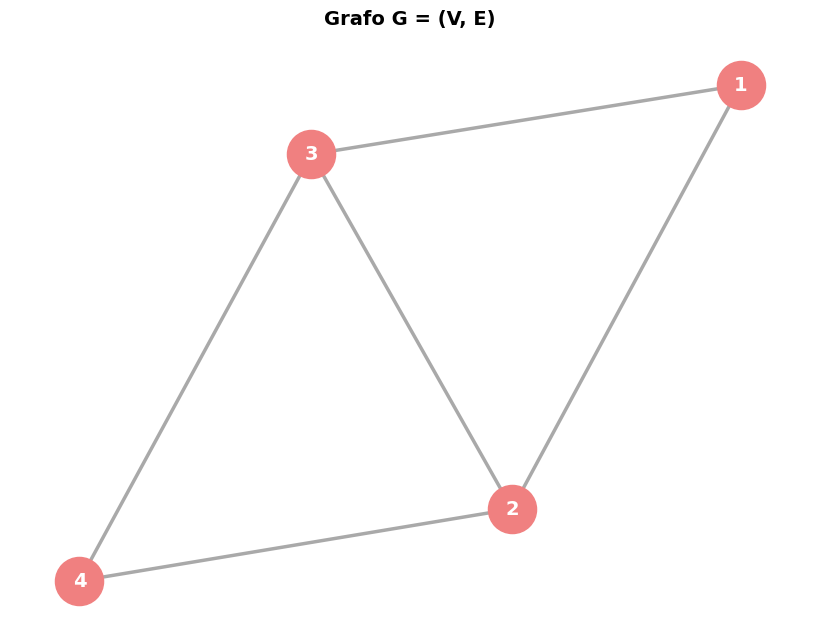

In [13]:
# Visualização do grafo G
plt.figure(figsize=(8, 6))
pos = nx.spring_layout(G, seed=42)
nx.draw(G, pos, 
        with_labels=True, 
        node_color='lightcoral', 
        node_size=1200,
        font_size=14,
        font_weight='bold',
        font_color='white',
        edge_color='darkgray',
        width=2.5)
plt.title('Grafo G = (V, E)', fontsize=14, fontweight='bold')
plt.axis('off')
plt.tight_layout()
plt.show()

---

## 3. Representações de Grafos no NetworkX

### Diferentes formas de criar grafos:

In [14]:
# Forma 1: Adicionando vértices e arestas separadamente
G1 = nx.Graph()
G1.add_nodes_from([1, 2, 3, 4])
G1.add_edges_from([(1, 2), (2, 3), (3, 4), (4, 1)])

print("Forma 1 - Criação manual:")
print(f"Vértices: {list(G1.nodes())}")
print(f"Arestas: {list(G1.edges())}")

Forma 1 - Criação manual:
Vértices: [1, 2, 3, 4]
Arestas: [(1, 2), (1, 4), (2, 3), (3, 4)]


In [15]:
# Forma 2: Usando dicionário de adjacência
adj_dict = {
    1: [2, 4],
    2: [1, 3],
    3: [2, 4],
    4: [3, 1]
}
G2 = nx.from_dict_of_lists(adj_dict)

print("\nForma 2 - Dicionário de adjacência:")
print(f"Vértices: {list(G2.nodes())}")
print(f"Arestas: {list(G2.edges())}")


Forma 2 - Dicionário de adjacência:
Vértices: [1, 2, 3, 4]
Arestas: [(1, 2), (1, 4), (2, 3), (3, 4)]


In [16]:
# Forma 3: Criando grafos especiais pré-definidos
G3 = nx.cycle_graph(4)  # Grafo ciclo com 4 vértices

print("\nForma 3 - Grafo pré-definido (ciclo):")
print(f"Vértices: {list(G3.nodes())}")
print(f"Arestas: {list(G3.edges())}")


Forma 3 - Grafo pré-definido (ciclo):
Vértices: [0, 1, 2, 3]
Arestas: [(0, 1), (0, 3), (1, 2), (2, 3)]


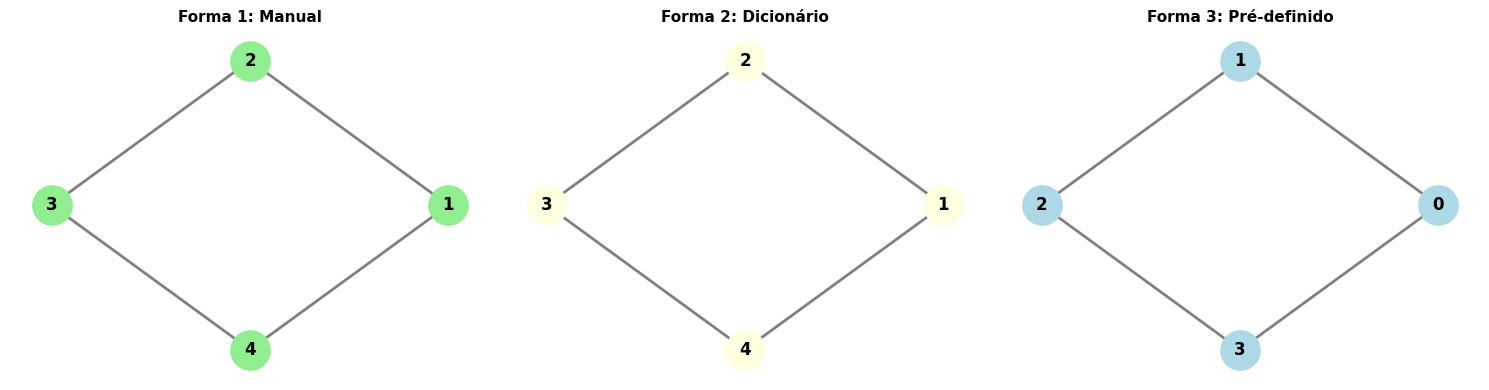

In [17]:
# Comparação visual das três formas
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
grafos = [G1, G2, G3]
titulos = ['Forma 1: Manual', 'Forma 2: Dicionário', 'Forma 3: Pré-definido']
cores = ['lightgreen', 'lightyellow', 'lightblue']

for i, (g, titulo, cor) in enumerate(zip(grafos, titulos, cores)):
    pos = nx.circular_layout(g)
    nx.draw(g, pos, ax=axes[i],
            with_labels=True, 
            node_color=cor, 
            node_size=800,
            font_size=12,
            font_weight='bold',
            edge_color='gray',
            width=2)
    axes[i].set_title(titulo, fontsize=11, fontweight='bold')
    axes[i].axis('off')

plt.tight_layout()
plt.show()

---

## 4. Exercícios Práticos

### Exercício 1: Crie seu próprio grafo

Modifique o código abaixo para criar um grafo representando uma rede social com 5 pessoas.

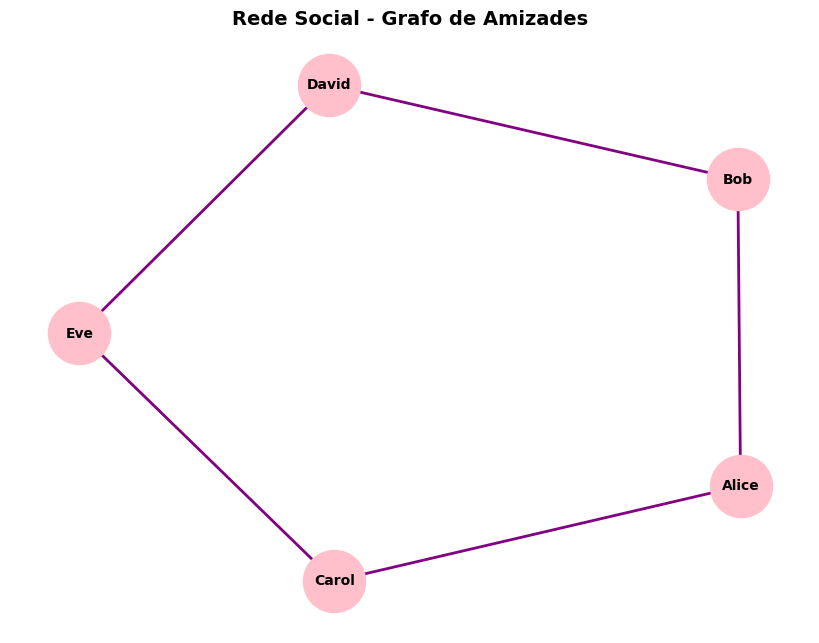

Pessoas na rede: ['Alice', 'Bob', 'Carol', 'David', 'Eve']
Amizades: [('Alice', 'Bob'), ('Alice', 'Carol'), ('Bob', 'David'), ('Carol', 'Eve'), ('David', 'Eve')]

Total de pessoas: 5
Total de amizades: 5


In [18]:
# Exercício: Rede social com 5 pessoas
# TODO: Complete o código abaixo

rede_social = nx.Graph()

# Adicione 5 pessoas (vértices)
pessoas = ['Alice', 'Bob', 'Carol', 'David', 'Eve']
rede_social.add_nodes_from(pessoas)

# Adicione amizades (arestas)
amizades = [
    ('Alice', 'Bob'),
    ('Alice', 'Carol'),
    ('Bob', 'David'),
    ('Carol', 'Eve'),
    ('David', 'Eve')
]
rede_social.add_edges_from(amizades)

# Visualização
plt.figure(figsize=(8, 6))
pos = nx.spring_layout(rede_social, seed=42)
nx.draw(rede_social, pos, 
        with_labels=True, 
        node_color='pink', 
        node_size=2000,
        font_size=10,
        font_weight='bold',
        edge_color='purple',
        width=2)
plt.title('Rede Social - Grafo de Amizades', fontsize=14, fontweight='bold')
plt.axis('off')
plt.tight_layout()
plt.show()

print(f"Pessoas na rede: {list(rede_social.nodes())}")
print(f"Amizades: {list(rede_social.edges())}")
print(f"\nTotal de pessoas: {rede_social.number_of_nodes()}")
print(f"Total de amizades: {rede_social.number_of_edges()}")

---

## 📌 Resumo

Neste notebook, aprendemos:

1. ✅ **Motivação**: Grafos modelam relações entre objetos (ex: sistemas computacionais)
2. ✅ **Definição formal**: $G = (V, E)$ onde $V$ = vértices e $E$ = arestas
3. ✅ **NetworkX**: Biblioteca Python para criar e manipular grafos
4. ✅ **Representações**: Várias formas de criar grafos no Python

### 🎯 Próximo notebook:
**02_terminologia.ipynb** - Terminologia básica de grafos (vértices adjacentes, arestas incidentes, laços, etc.)